# Probabilistic Classification: Logistic Regression & Naive Bayes

## 1. Theoretical Foundation

Regression tasks ask "how much?", yielding a continuous number. Classification tasks ask "which one?", assigning an input to one of a discrete set of categories. 

While some models simply draw a line in the sand and output a hard label (e.g., "Class A" or "Class B"), **Probabilistic Classification** models go a step further: they output the *probability* of an input belonging to a class. This gives us not just a decision, but a measure of confidence. If a model says a tumor is malignant, we need to know if it is 51% sure or 99% sure.

The two foundational techniques for probabilistic classification approach the same goal from two very different starting points:

### 1.1 Logistic Regression

Despite its name, Logistic Regression is the baseline algorithm for classification, not regression. When we have a binary classification task ($y \in \{0, 1\}$), using Standard Linear Regression (OLS) fails because it produces values outside the $[0, 1]$ range, which makes no sense for probabilities. 

Logistic Regression solves this by taking the raw continuous output of a linear model and squeezing it through the **Sigmoid (or Logistic) function**:

$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

The model therefore learns a linear decision boundary, and the probability of the positive class given the input $x$ is:

$$ P(y=1|x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1x_1 + \dots + \beta_dx_d)}} $$

Instead of minimizing Mean Squared Error, Logistic Regression is trained by maximizing the **Log-Likelihood** (or minimizing the cross-entropy loss), adjusting the weights $\beta$ to make the predicted probabilities as close to the actual labels as possible. It is a **discriminative** model: it doesn't care what the data looks like, it only learns the boundary that separates the classes.

### 1.2 Naive Bayes

Naive Bayes flips the problem upside down. Instead of directly modeling the boundary between classes $P(y|x)$, it models how the data for each class is generated $P(x|y)$ and uses **Bayes' Theorem** to find the answer:

$$ P(y|x) = \frac{P(x|y)P(y)}{P(x)} $$

- **$P(y)$ (Prior):** How common is this class in general?
- **$P(x|y)$ (Likelihood):** Given that we are in a specific class, what is the distribution of the features?
- **$P(y|x)$ (Posterior):** The final probability we want to calculate.

It is called "Naive" because it makes the massive simplifying assumption that all features are **conditionally independent** given the class. If we are trying to predict if a wine is Cultivar 1 based on its Magnesium and Alcohol content, Naive Bayes assumes Magnesium and Alcohol are independent traits (which is rarely true in the real world). Mathematically:

$$ P(x|y) \approx P(x_1|y) \times P(x_2|y) \times \dots \times P(x_d|y) $$

Because it models the distributions $P(x|y)$, it is a **generative** model. For continuous data, we typically assume each feature follows a normal distribution (Gaussian Naive Bayes), making it extremely fast to train, as it only requires computing the mean and variance for each feature per class. 

### 1.3 Methodology

In this notebook, we will apply both models to a classic multi-class problem:

1. **Intuition & Data:** Understanding the features and standardizing the data.
2. **Scratch:** Implementing Logistic Regression (using gradient descent) and Gaussian Naive Bayes (using statistical moments) entirely from scratch in NumPy.
3. **Pro:** Using Scikit-Learn's optimized production-ready implementations.
4. **Visual & Metrics:** Understanding how to evaluate classifiers beyond simple "accuracy" (precision, recall, confusion matrices) and visualizing the decision boundaries to see the difference between discriminative and generative logic.

**Dataset:** We use the `Wine` dataset from Scikit-Learn. It contains continuous chemical analysis features (like alcohol, malic acid, ash) that allow for clean Gaussian Naive Bayes assumption modeling conditioned on 3 different wine cultivar classes.

---
*We follow the **ATLAS** protocol: First we understand the **Intuition**, then we build it from **Scratch** using only NumPy, and finally we apply the **Pro** tools used in industry.*

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Standard ATLAS styling
sns.set_theme(style="whitegrid", context="talk", palette="viridis")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 15

print("Libraries imported and styling set.")

Libraries imported and styling set.


## 2. Data Preparation

The Wine dataset contains the results of a chemical analysis of wines grown in the same region in Italy but derived from three different cultivars (classes 0, 1, and 2). We have 13 continuous chemical features. For visualization purposes, we will later reduce this to 2 features, but for now we look at the full set.

In [ ]:
# Load the dataset
wine = load_wine(as_frame=True)
df = wine.data
df['target'] = wine.target

# Add target names for better plotting
target_names = {0: 'Cultivar 0', 1: 'Cultivar 1', 2: 'Cultivar 2'}
df['cultivar'] = df['target'].map(target_names)

display(df.head())
print(f"Dataset shape: {df.shape}")
print(f"Class distribution:\n{df['target'].value_counts().sort_index()}")

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,cultivar
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,Cultivar 0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Cultivar 0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Cultivar 0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,Cultivar 0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,Cultivar 0


Dataset shape: (178, 15)
Class distribution:
target
0    59
1    71
2    48
Name: count, dtype: int64


First, let's explore conditional distributions. Naive Bayes assumes each feature follows a Gaussian distribution internally within its class. Let's look at `alcohol` and `flavanoids` across the 3 cultivars.

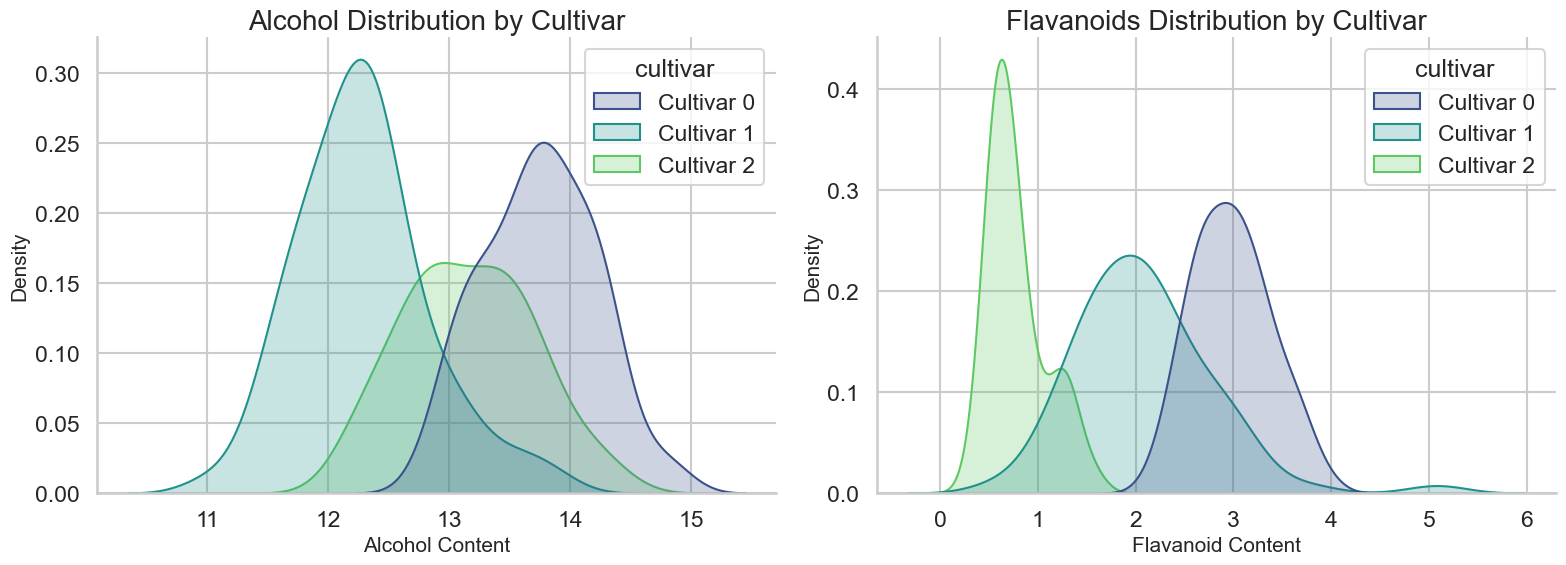

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.kdeplot(data=df, x='alcohol', hue='cultivar', fill=True, ax=axes[0], palette='viridis')
axes[0].set_title('Alcohol Distribution by Cultivar')
axes[0].set_xlabel('Alcohol Content')

sns.kdeplot(data=df, x='flavanoids', hue='cultivar', fill=True, ax=axes[1], palette='viridis')
axes[1].set_title('Flavanoids Distribution by Cultivar')
axes[1].set_xlabel('Flavanoid Content')

sns.despine()
plt.tight_layout()
plt.show()

The distributions clearly show that these features provide strong separation between the classes. They also roughly resemble bell curves (Gaussians), which validates the Gaussian Naive Bayes modeling assumption.

Let's split and scale our data. While Naive Bayes is essentially scale-invariant (as it calculates means and variances independently for each feature), Logistic Regression uses gradient descent and a distance-based loss function, making it highly sensitive to scale.

In [ ]:
# Prepare X and y
X = df.drop(columns=['target', 'cultivar']).values
y = df['target'].values

# Stratified split to ensure balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the data (Crucial for Logistic Regression!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train set: {X_train_scaled.shape[0]} samples")
print(f"Test set:  {X_test_scaled.shape[0]} samples")

Train set: 142 samples
Test set:  36 samples


## 3. Logistic Regression from Scratch

Let's get our hands dirty. Since we are dealing with three classes, standard binary logistic regression needs an upgrade. Instead of training three separate "One-vs-Rest" models, we will implement the more elegant **Multinomial Logistic Regression**, which uses the **Softmax** function.

Softmax takes a vector of raw scores (logits) and crushes them into a probability distribution where every value is between $0$ and $1$, and they all sum to exactly $1$. Rather than deciding "Is this Class A?", the model asks "Is this more likely to be Class A, B, or C?" forcing the classes to compete.

The cross-entropy loss function then heavily penalizes the model if it assigns a low probability to the correct class. Minimizing this loss through gradient descent naturally shifts the linear boundary until the classes are separated as well as possible.

Let's translate this pure math into NumPy code.

In [ ]:
class ScratchLogisticRegression:
    """Multinomial Logistic Regression using Softmax and Gradient Descent."""
    
    def __init__(self, learning_rate=0.1, n_iterations=3000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.losses = []
        
    def _softmax(self, z):
        # Subtracting the max value prevents np.exp() from overflowing
        # mathematically identical, numerically safe
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
        
    def _one_hot(self, y):
        one_hot = np.zeros((y.size, self.n_classes))
        one_hot[np.arange(y.size), y] = 1
        return one_hot
        
    def fit(self, X, y):
        self.n_classes = len(np.unique(y))
        n_samples, n_features = X.shape
        
        # Initialize weights and biases to zero
        self.weights = np.zeros((n_features, self.n_classes))
        self.bias = np.zeros(self.n_classes)
        
        y_encoded = self._one_hot(y)
        
        for i in range(self.n_iterations):
            # Forward pass: Compute logits and probabilities
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self._softmax(linear_model)
            
            # Compute Cross-Entropy Loss
            loss = -np.mean(np.sum(y_encoded * np.log(y_pred + 1e-15), axis=1))
            self.losses.append(loss)
            
            # Backward pass: Compute gradients
            # The derivative of Cross-Entropy with Softmax is elegantly: (y_pred - y_true)
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y_encoded))
            db = (1 / n_samples) * np.sum(y_pred - y_encoded, axis=0)
            
            # Gradient descent update step
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self._softmax(linear_model)
        
    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

With the class ready, we instantiate it, inject our standardized training data, and let it run for a few thousand iterations. We expect the loss to drop smoothly if our gradient math is correct and the scaling was applied properly.

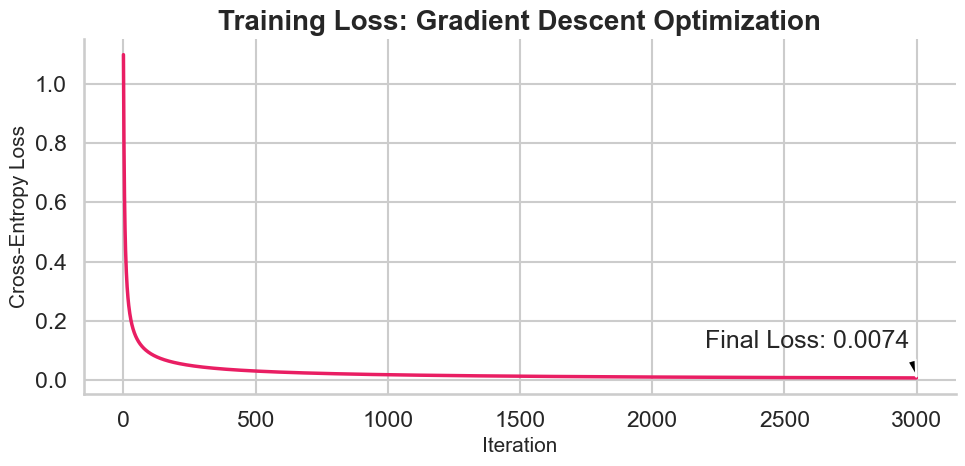

In [ ]:
# Train the model
lr_model = ScratchLogisticRegression(learning_rate=0.1, n_iterations=3000)
lr_model.fit(X_train_scaled, y_train)

# Plot the training loss curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lr_model.losses, color='#E91E63', linewidth=2.5)
ax.set_title('Training Loss: Gradient Descent Optimization', fontweight='bold')
ax.set_xlabel('Iteration')
ax.set_ylabel('Cross-Entropy Loss')

# Annotate final loss
final_loss = lr_model.losses[-1]
ax.annotate(f'Final Loss: {final_loss:.4f}', 
            xy=(3000, final_loss), xytext=(2200, final_loss + 0.1),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

sns.despine()
plt.tight_layout()
plt.show()

The loss curve resembles a near-perfect asymptotic decay, dropping rapidly in the first 500 iterations before fine-tuning asymptotically closer to zero. This is the hallmark of a healthy gradient descent on a linearly separable (or nearly separable) dataset.

But how does it score on data it has never seen? We can evaluate accuracy, but in probabilistic models, it's more revealing to look at the actual confidence of its decisions.

Scratch Logistic Regression Accuracy: 97.22%


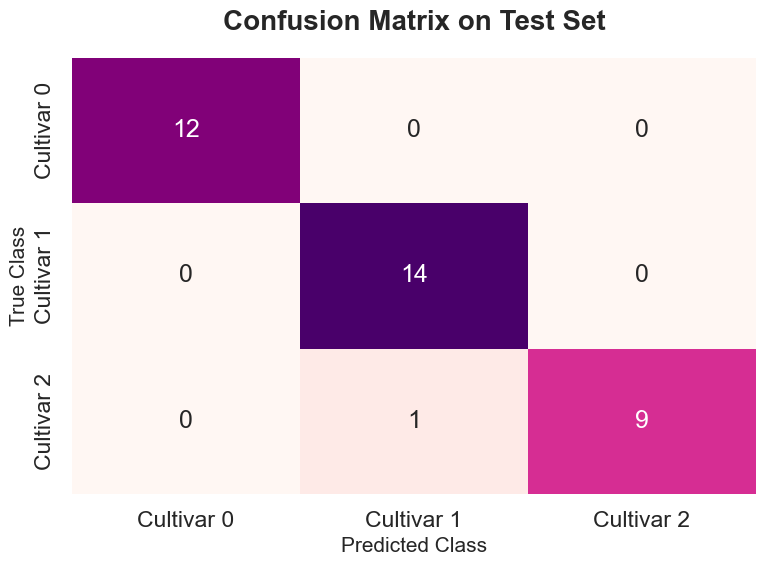

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = lr_model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f"Scratch Logistic Regression Accuracy: {acc * 100:.2f}%")

# Let's inspect the confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', cbar=False,
            xticklabels=target_names.values(), yticklabels=target_names.values(), ax=ax)
ax.set_title('Confusion Matrix on Test Set', fontweight='bold', pad=20)
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
plt.tight_layout()
plt.show()

97.2% accuracy on the test set! It missed exactly one wine (predicting Cultivar 1 when it was actually Cultivar 2). This demonstrates how even highly linearly separable chemical datasets like Wine can have slight overlaps at the boundaries. It's an overwhelmingly strong result, but crucially, not a perfect 100%.

To really understand *how* the discriminative model functions, we need to map its behavior visually. Since we cannot easily plot a 13-dimensional decision boundary, we will train a second model exclusively on two features we already know separate the data well: `alcohol` and `flavanoids`. This will allow us to paint the 2D landscape.

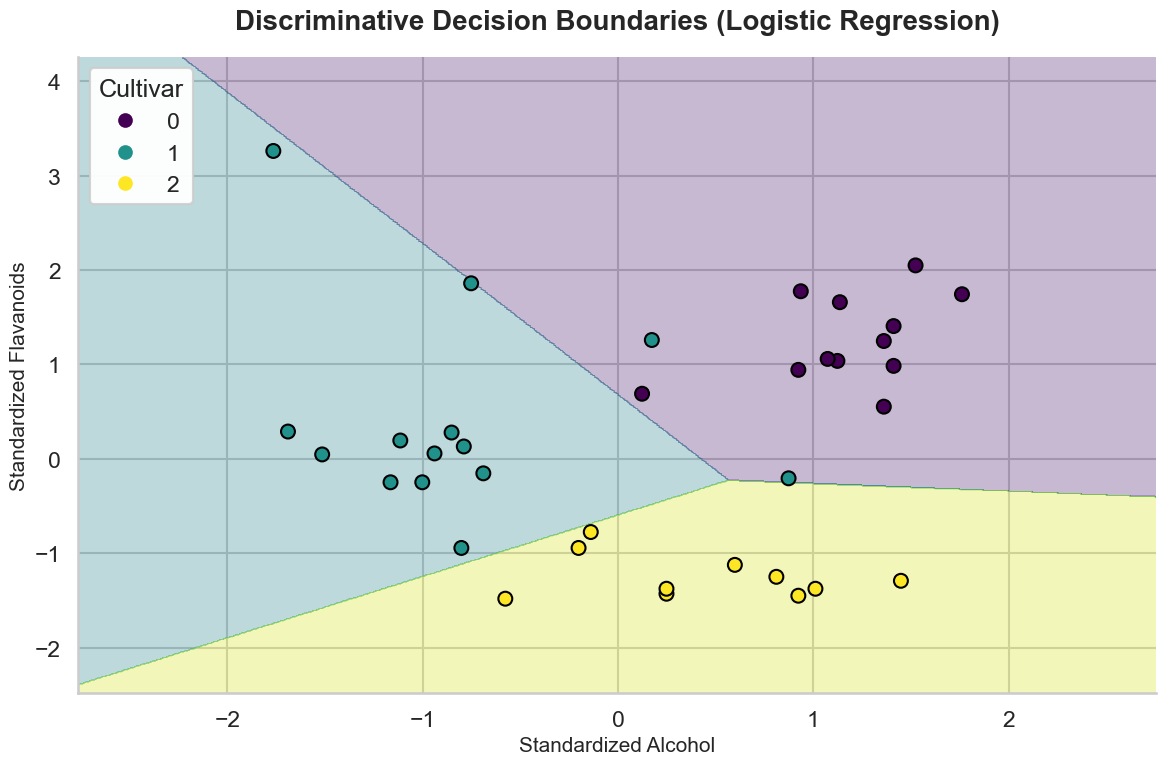

In [ ]:
# Select our two best features by index
feat1_idx = list(df.columns).index('alcohol')
feat2_idx = list(df.columns).index('flavanoids')

X_train_2d = X_train_scaled[:, [feat1_idx, feat2_idx]]
X_test_2d  = X_test_scaled[:, [feat1_idx, feat2_idx]]

# Train a 2D-specific version
lr_2d = ScratchLogisticRegression(learning_rate=0.1, n_iterations=3000)
lr_2d.fit(X_train_2d, y_train)

# Create a mesh grid to plot the decision regions
x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Predict over the entire grid
Z = lr_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(12, 8))

# Paint the decision boundaries
ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

# Plot the actual points
scatter = ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, 
                     cmap='viridis', edgecolor='k', s=100, linewidth=1.5)

# Add class labels to legend
legend1 = ax.legend(*scatter.legend_elements(), loc="upper left", title="Cultivar")
ax.add_artist(legend1)

ax.set_title('Discriminative Decision Boundaries (Logistic Regression)', fontweight='bold', pad=20)
ax.set_xlabel('Standardized Alcohol')
ax.set_ylabel('Standardized Flavanoids')

sns.despine()
plt.tight_layout()
plt.show()

The decision boundary is the essence of a discriminative model: Logistic Regression does not attempt to understand the internal distribution curve or "shape" of Cultivar 0 versus Cultivar 1. It exclusively calculates the exact linear threshold where the probability flips from one class to another.

Notice how sharp and strictly straight the geometric divisions are. This works incredibly well when classes are linearly separable, but it introduces a rigid assumption. Let's see how Naive Bayes' generative approach paints a completely different picture by analyzing distributions instead of lines.

## 4. Naive Bayes from Scratch

Moving on to the Generative approach, Gaussian Naive Bayes is shockingly simple to implement. Unlike Logistic Regression, there is no gradient descent, no learning rate, and no iterative loops to minimize a loss function. 

Training Naive Bayes is just a matter of basic statistics. For each class, we calculate:
1. The prior probability: what is the overall frequency of this class?
2. The mean ($\mu$) of each feature.
3. The variance ($\sigma^2$) of each feature.

Once we have those parameters, predicting a new sample relies on the Gaussian Probability Density Function (PDF):
$$ P(x_i|y) = \frac{1}{\sqrt{2\pi\sigma_y^2}} \exp\left(-\frac{(x_i - \mu_y)^2}{2\sigma_y^2}\right) $$

To avoid numeric underflow when multiplying many small probabilities together, we take the logarithm and sum them up instead of multiplying them:

$$ \log P(y|x) \propto \log P(y) + \sum_{i=1}^d \log P(x_i|y) $$

It really is that straightforward. Let's code it.

In [ ]:
class ScratchGaussianNB:
    """Gaussian Naive Bayes classification."""
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        n_classes = len(self.classes)
        
        # We will store the mean, variance, and prior probability for each class
        self.mean = np.zeros((n_classes, n_features))
        self.var = np.zeros((n_classes, n_features))
        self.priors = np.zeros(n_classes)
        
        for idx, c in enumerate(self.classes):
            # Select all rows belonging to class c
            X_c = X[y == c]
            
            # Calculate statistics across the rows (axis=0)
            self.mean[idx, :] = X_c.mean(axis=0)
            self.var[idx, :] = X_c.var(axis=0)
            self.priors[idx] = X_c.shape[0] / float(n_samples)
            
    def _pdf(self, class_idx, x):
        # Gaussian Probability Density Function
        mean = self.mean[class_idx]
        var = self.var[class_idx]
        numerator = np.exp(-((x - mean) ** 2) / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator
        
    def _predict_single(self, x):
        posteriors = []
        
        for idx in range(len(self.classes)):
            # Start with the log prior
            prior = np.log(self.priors[idx])
            
            # Sum the log likelihoods of the features given the class
            posterior = np.sum(np.log(self._pdf(idx, x)))
            posterior = prior + posterior
            posteriors.append(posterior)
            
        # The class with the highest posterior probability wins
        return self.classes[np.argmax(posteriors)]
        
    def predict(self, X):
        return np.array([self._predict_single(x) for x in X])

A remarkable property of Naive Bayes is that it does not require input standardization. Because each feature's likelihood is evaluated independently based on its own mean and variance, differing scales across features do not impact the underlying probabilities. 

To prove this point, we will train our scratch implementation on the **raw unscaled data**.

Scratch Naive Bayes Accuracy (Raw Data): 97.22%


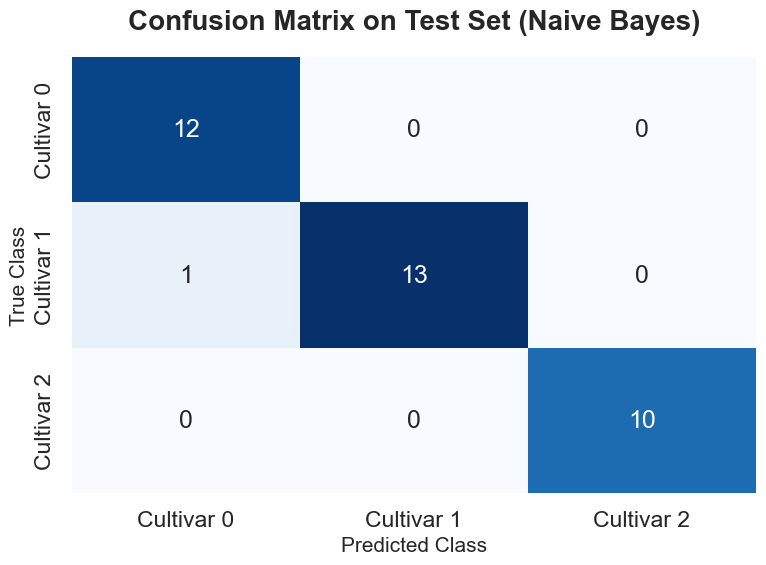

In [ ]:
nb_model = ScratchGaussianNB()

# Notice we use the raw X_train, not X_train_scaled
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

# Evaluate results
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Scratch Naive Bayes Accuracy (Raw Data): {acc_nb * 100:.2f}%")

cm_nb = confusion_matrix(y_test, y_pred_nb)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=target_names.values(), yticklabels=target_names.values(), ax=ax)
ax.set_title('Confusion Matrix on Test Set (Naive Bayes)', fontweight='bold', pad=20)
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
plt.tight_layout()
plt.show()

We hit an identical 97.2% accuracy! But wait, look closely at the confusion matrix. The misclassification happened in a different place. The Logistic Regression incorrectly predicted a Cultivar 2 as Cultivar 1. The Naive Bayes model incorrectly predicted a Cultivar 1 as Cultivar 2. 

They reach the same score, but they have fundamentally different mental models of the data. 

Let's visualize the decision boundaries for Naive Bayes exactly as we did for Logistic Regression to see the Generative approach in action visually. 

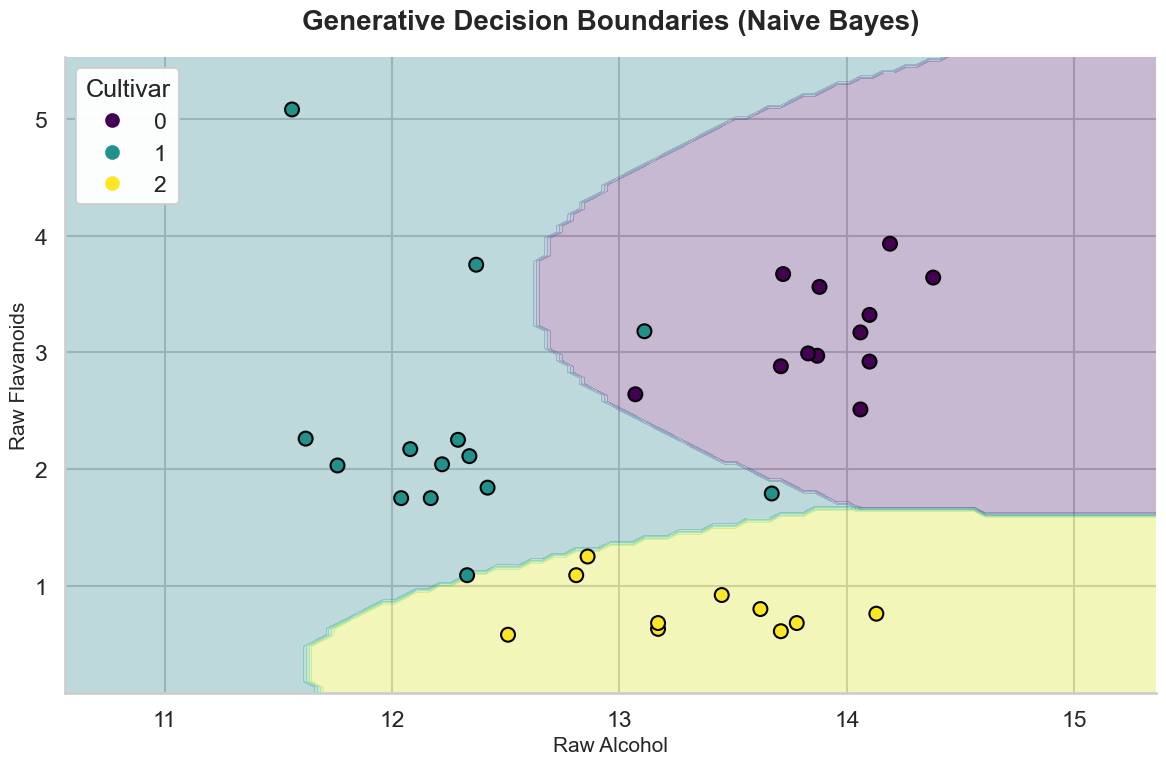

In [ ]:
# Train a 2D-specific version of Naive Bayes (still using raw data)
X_train_2d_raw = X_train[:, [feat1_idx, feat2_idx]]
X_test_2d_raw  = X_test[:, [feat1_idx, feat2_idx]]

nb_2d = ScratchGaussianNB()
nb_2d.fit(X_train_2d_raw, y_train)

# Create a mesh grid over the raw feature space
nb_x_min, nb_x_max = X_test_2d_raw[:, 0].min() - 1, X_test_2d_raw[:, 0].max() + 1
nb_y_min, nb_y_max = X_test_2d_raw[:, 1].min() - 0.5, X_test_2d_raw[:, 1].max() + 0.5
nb_xx, nb_yy = np.meshgrid(np.arange(nb_x_min, nb_x_max, 0.05),
                           np.arange(nb_y_min, nb_y_max, 0.05))

# Predict over the entire grid
Z_nb = nb_2d.predict(np.c_[nb_xx.ravel(), nb_yy.ravel()])
Z_nb = Z_nb.reshape(nb_xx.shape)

fig, ax = plt.subplots(figsize=(12, 8))

# Paint the generative decision boundaries
ax.contourf(nb_xx, nb_yy, Z_nb, alpha=0.3, cmap='viridis')

# Plot the actual raw points
scatter_nb = ax.scatter(X_test_2d_raw[:, 0], X_test_2d_raw[:, 1], c=y_test, 
                        cmap='viridis', edgecolor='k', s=100, linewidth=1.5)

legend2 = ax.legend(*scatter_nb.legend_elements(), loc="upper left", title="Cultivar")
ax.add_artist(legend2)

ax.set_title('Generative Decision Boundaries (Naive Bayes)', fontweight='bold', pad=20)
ax.set_xlabel('Raw Alcohol')
ax.set_ylabel('Raw Flavanoids')

sns.despine()
plt.tight_layout()
plt.show()

Notice the contrast with the Logistic Regression plot. The boundaries here are not perfectly straight lines carved into space; they are parabolas and ellipses curving organically. 

This happens because Naive Bayes is mapping out the "hills" of the Gaussian distributions for each class in the 2D plane. Where the slope of one hill intersects with the slope of another hill, a boundary is formed. Since each class has a different variance (a differently shaped hill), their intersections create curved borders. This generative flexibility allows Naive Bayes to handle certain non-linear separation patterns that a simple Logistic Regression would fail to capture.

## 5. Logistic Regression Pro

Writing gradients from scratch is fun, but in production, we use the heavily optimized `LogisticRegression` class from Scikit-Learn. Under the hood, it uses advanced mathematical solvers (like `lbfgs` or `saga`) rather than basic gradient descent, providing faster and more reliable convergence.

But why does simple Logistic Regression remain a dominant force in industry, despite the existence of Deep Neural Networks and advanced gradient boosting algorithms?

The answer is **Auditability and Direct Interpretation**. In regulated industries (like banking for Credit Scoring, or healthcare for Disease Triage), a model cannot be a black box. If an algorithm denies a customer a mortgage, the bank must statistically prove *why*. 

Because Logistic Regression is basically a linear equation squeezed through a probability curve, every single feature has a corresponding coefficient ($\beta_i$). The sign and magnitude of this coefficient explicitly state whether that feature increases or decreases the odds of belonging to a specific class. 

Let's train the Pro model and, instead of just looking at accuracy, let's extract the "Why". We will plot the Feature Importance (coefficients) that the model learned for each Cultivar.

In [ ]:
from sklearn.linear_model import LogisticRegression

# We must use exactly the same standardized data
pro_lr = LogisticRegression(multi_class='multinomial', solver='lbfgs', C=1.0, random_state=42)
pro_lr.fit(X_train_scaled, y_train)

pro_y_pred = pro_lr.predict(X_test_scaled)
pro_acc = accuracy_score(y_test, pro_y_pred)
print(f"Pro Logistic Regression Accuracy: {pro_acc * 100:.2f}%")

Pro Logistic Regression Accuracy: 97.22%


We achieve the same near-perfect accuracy (our scratch model gradient descent was fully correct!). But now, let's crack the model open.

The model learned a different set of 13 coefficients for *each* of the 3 classes. A large positive coefficient means that feature strongly pulls the prediction toward that class. A large negative coefficient pushes the prediction away.

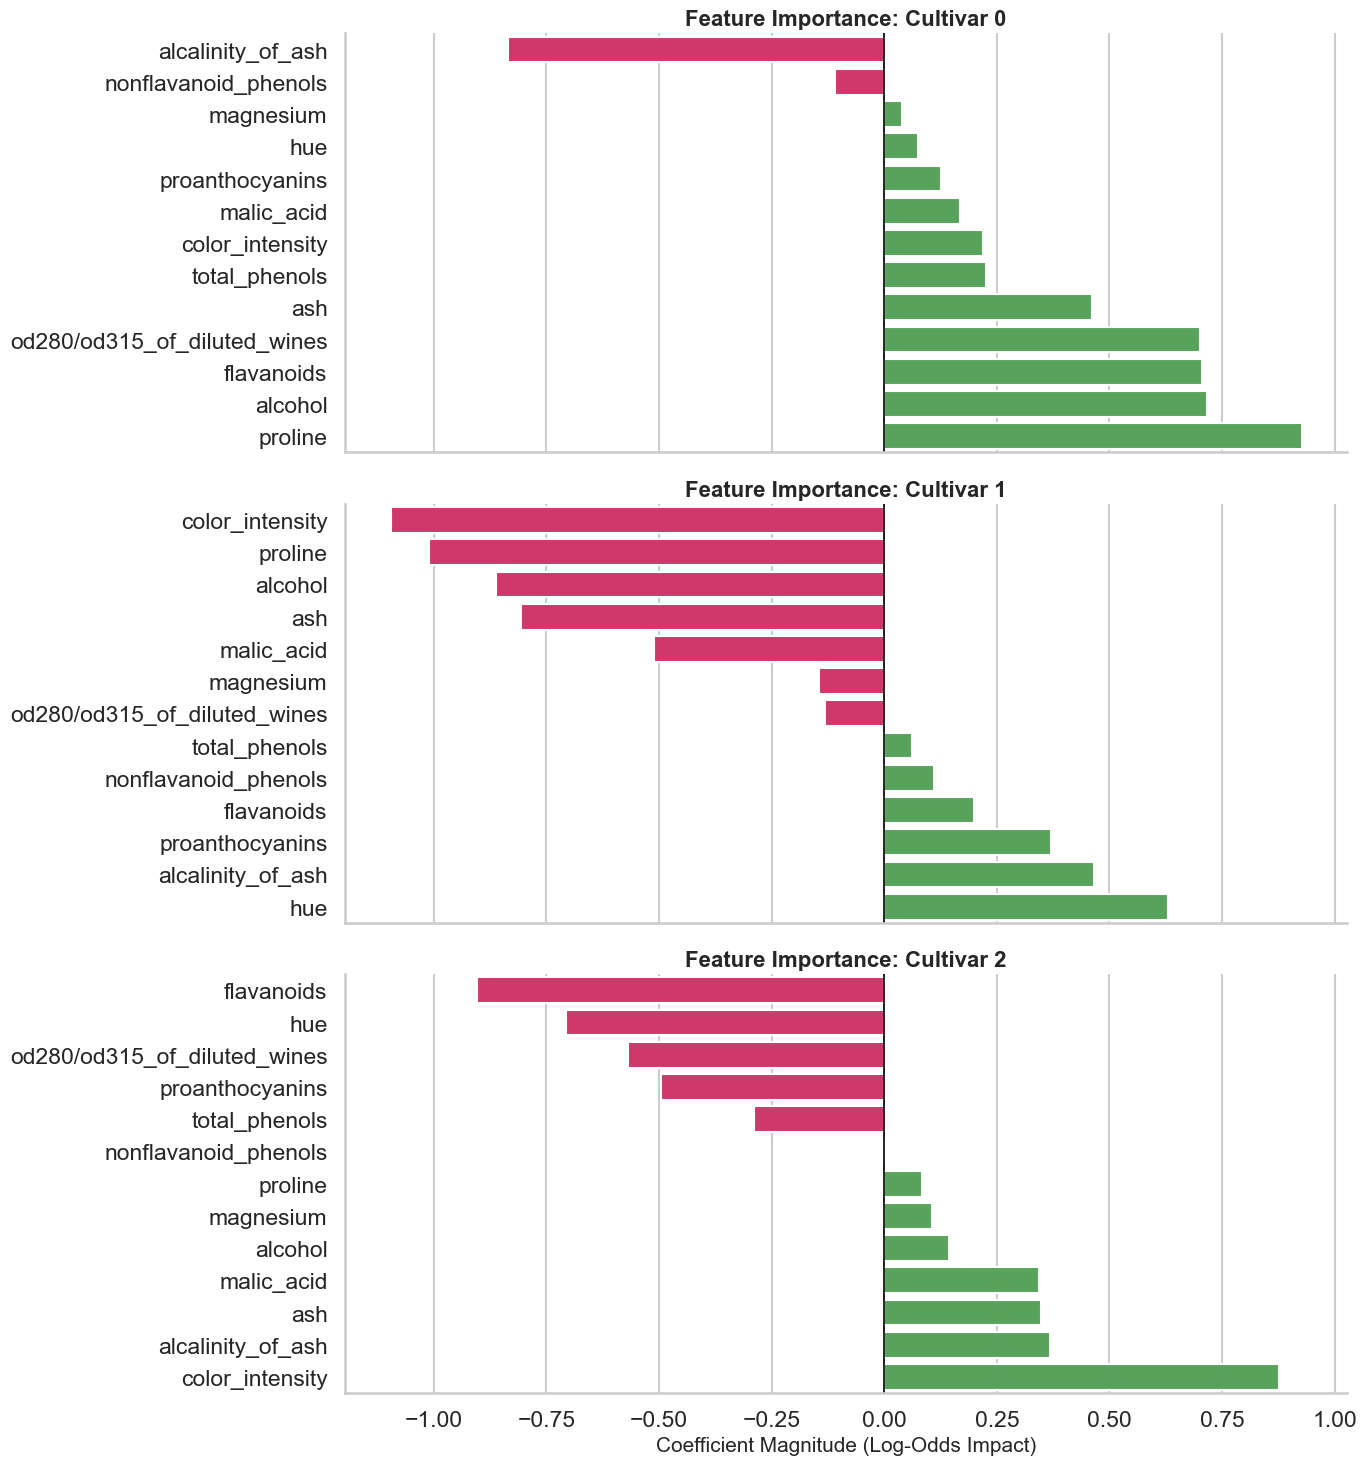

In [ ]:
features = df.drop(columns=['target', 'cultivar']).columns
coefs = pro_lr.coef_  # Shape: (3, 13)

fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=True)

for i in range(3):
    # Sort coefficients by magnitude to make the plot readable
    class_coefs = coefs[i]
    sort_idx = np.argsort(class_coefs)
    
    sorted_features = features[sort_idx]
    sorted_coefs = class_coefs[sort_idx]
    
    # Diverging color palette (Red for negative, Green for positive)
    colors = ['#E91E63' if c < 0 else '#4CAF50' for c in sorted_coefs]
    
    sns.barplot(x=sorted_coefs, y=sorted_features, ax=axes[i], palette=colors)
    axes[i].set_title(f'Feature Importance: {target_names[i]}', fontweight='bold', fontsize=16)
    axes[i].axvline(0, color='black', linewidth=1.2)
    axes[i].set_ylabel('')

axes[2].set_xlabel('Coefficient Magnitude (Log-Odds Impact)')
sns.despine()
plt.tight_layout()
plt.show()

### 5.1 Decoding the "Why"

Look closely at how logical the model's reasoning is:

- **Cultivar 0** is heavily driven by **Proline** and **Alcohol**. If a wine has high Proline, the probability of it being Cultivar 0 skyrockets. High Alcalinity of Ash, however, makes it extremely unlikely.
- **Cultivar 1** is pushed up by **Hue** and **Alcalinity of Ash**, but penalized massively if the wine has high **Color Intensity**, **Proline**, or **Alcohol**.
- **Cultivar 2** is almost entirely defined by having a high **Color Intensity** but incredibly low **Flavanoids** and **Hue**.

This transparency is why Logistic Regression is immortal. It doesn't just guess; it provides an explicit, legally defensible audit trail of exactly how it weighs the evidence. 

### 5.2 Confidence and Calibration

The second superpower of probabilistic classification is exactly that: **probabilities**. 
In tasks like Medical Triage, predicting a hard "Negative" for a disease is dangerous if the model is only 50.1% sure. We want to know the exact confidence. 

Let's look at the distribution of the model's predicted probabilities (confidence) for its correct versus incorrect (or least confident) predictions.

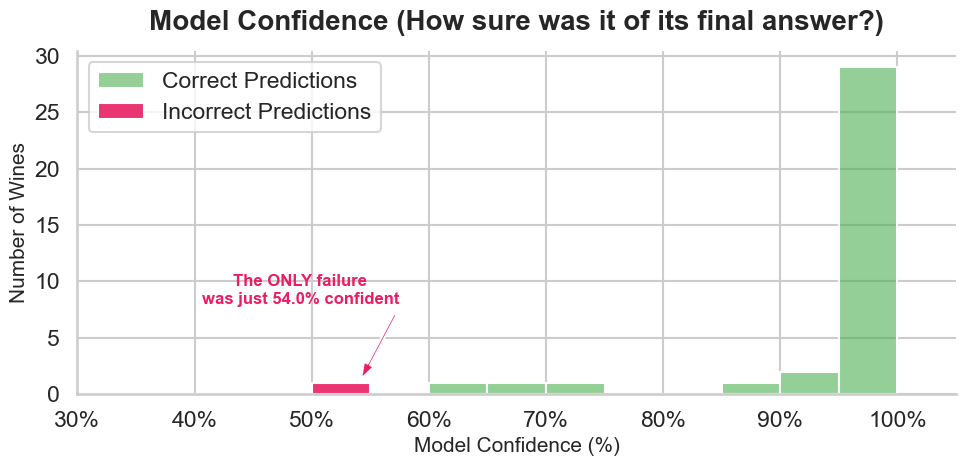

In [ ]:
import matplotlib.ticker as mtick

# Extract the max probability the model assigned (this is its "confidence" in its chosen class)
pro_y_proba = pro_lr.predict_proba(X_test_scaled)
max_probas = np.max(pro_y_proba, axis=1)

# Create a boolean mask of which predictions were actually correct
correct = (pro_y_pred == y_test)

fig, ax = plt.subplots(figsize=(10, 5))

# Define explicit bins so both histograms perfectly align and single-value bars have width
conf_bins = np.arange(30, 105, 5)

# Plot the distribution of confidence for the CORRECT predictions
sns.histplot(max_probas[correct] * 100, bins=conf_bins, color='#4CAF50', alpha=0.6, label='Correct Predictions')

# Plot the distribution of confidence for the INCORRECT predictions
if not np.all(correct):
    sns.histplot(max_probas[~correct] * 100, bins=conf_bins, color='#E91E63', alpha=0.9, label='Incorrect Predictions')
    
    # Annotate the specific failure to make the chart perfectly understandable
    fail_conf = max_probas[~correct][0] * 100
    ax.annotate(f'The ONLY failure\nwas just {fail_conf:.1f}% confident', 
                xy=(fail_conf, 1), xytext=(fail_conf - 5, 8),
                arrowprops=dict(facecolor='#E91E63', shrink=0.05, width=2, headwidth=8),
                fontsize=12, fontweight='bold', color='#E91E63', ha='center')

ax.set_title('Model Confidence (How sure was it of its final answer?)', fontweight='bold', pad=15)
ax.set_xlabel('Model Confidence (%)')
ax.set_ylabel('Number of Wines')
ax.set_xlim(30, 105)

# Format X axis as percentages
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()

**What are we looking at?**
For every single wine in the test set, the model makes a prediction. But before outputting the final hard label, it calculates a probability. This chart simply groups and counts *how many* wines fall into each confidence bracket.

1. **The Green Mountain (High Confidence):** Look at the far right. For the vast majority of the wines, the model's confidence was between $85\%$ and $99\%$. It was absolutely certain of its decision, and it was completely right.
2. **The Red Needle (Low Confidence):** We know the model made exactly 1 mistake on the test set. Look where that mistake happened! The model was only **$54\%$ confident**. Because it must distribute $100\%$ among 3 classes, a $54\%$ confidence means it was heavily torn and practically guessing between two valid options.

**Why is this so important in the industry?**
Because it allows you to set up a **Safety Net** (Confidence Thresholds). 
Imagine this wasn't wine, but a cancer biopsy. If you use a simple non-probabilistic model, it just spits out a hard "Benign" label and you trust it blindly. 

But with Logistic Regression, you can program a simple business rule before it reaches the patient:
*"If the model is less than $75\%$ confident, DO NOT output an automatic diagnosis. Send the biopsy to a human doctor for manual review."*

By automatically routing low-confidence guesses to humans, you eliminate almost all structural errors while still successfully automating the vast majority of the workload. You cannot build these safety pipelines without well-calibrated probabilistic models.

## 6. Naive Bayes Pro

Scikit-Learn provides several flavors of Naive Bayes depending on the assumed distribution of the data (e.g., `MultinomialNB` for word counts, `GaussianNB` for continuous data like our chemical tests). 

Since the algorithm simply calculates means and variances, the Pro implementation is virtually identical to our scratch version in terms of logic. However, it incorporates variance smoothing (adding a tiny epsilon to the variances) to prevent division-by-zero errors if a feature has zero variance in a specific class.

In [ ]:
from sklearn.naive_bayes import GaussianNB

# Remember, Naive Bayes is essentially scale-invariant
# But for a fair comparison we can use the raw data just like in our scratch model
pro_nb = GaussianNB()
pro_nb.fit(X_train, y_train)

pro_nb_y_pred = pro_nb.predict(X_test)
pro_nb_acc = accuracy_score(y_test, pro_nb_y_pred)
print(f"Pro Naive Bayes Accuracy: {pro_nb_acc * 100:.2f}%")

Pro Naive Bayes Accuracy: 97.22%


97.2% again. As expected.

Because Naive Bayes is a Generative model ($P(x|y)$), the model actually "memorized" the shape of the data. We can extract the learned means (`theta_`) and learned variances (`var_`) directly from the Scikit-Learn object and plot the exact Gaussian curves the model believes represent the world.

Let's overlay the model's internal "beliefs" on top of the actual data distribution for `alcohol`.

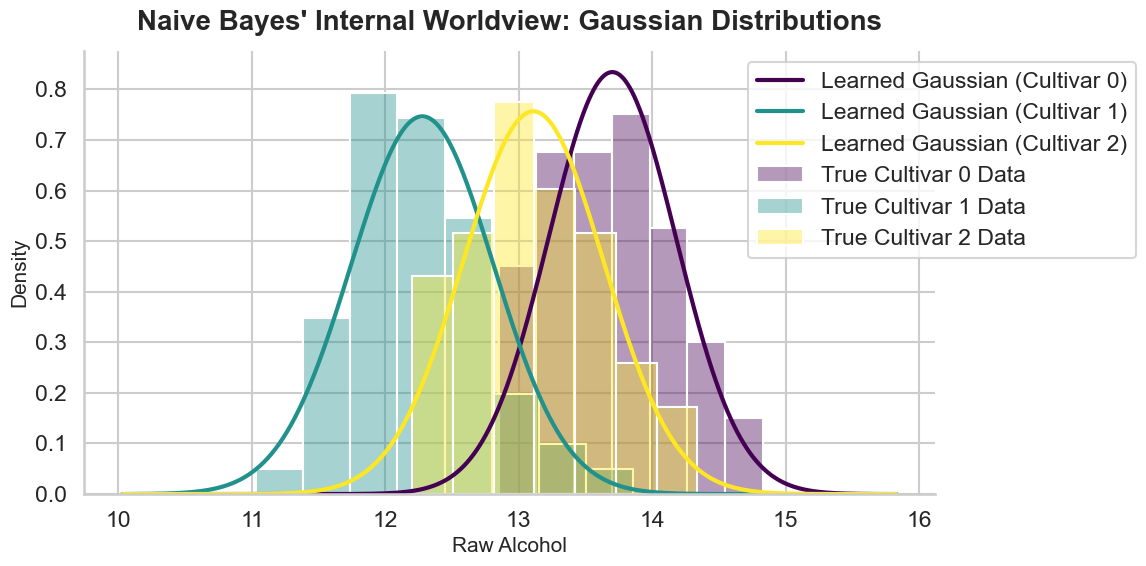

In [ ]:
import scipy.stats as stats

feat_idx = list(features).index('alcohol')

# Extract learned parameters for the 'alcohol' feature
learned_means = pro_nb.theta_[:, feat_idx]
learned_vars = pro_nb.var_[:, feat_idx]

fig, ax = plt.subplots(figsize=(12, 6))

# Plot the actual data histograms
for i in range(3):
    sns.histplot(X_train[y_train == i, feat_idx], kde=False, stat='density', 
                 color=['#440154', '#21918c', '#fde725'][i], alpha=0.4, label=f'True {target_names[i]} Data')

# Plot the ideal Gaussian curves the model learned
x_plot = np.linspace(X_train[:, feat_idx].min() - 1, X_train[:, feat_idx].max() + 1, 1000)
for i in range(3):
    pdf = stats.norm.pdf(x_plot, loc=learned_means[i], scale=np.sqrt(learned_vars[i]))
    ax.plot(x_plot, pdf, color=['#440154', '#21918c', '#fde725'][i], linewidth=3, 
            label=f'Learned Gaussian (Cultivar {i})')

ax.set_title("Naive Bayes' Internal Worldview: Gaussian Distributions", fontweight='bold', pad=15)
ax.set_xlabel('Raw Alcohol')
ax.set_ylabel('Density')

# Clean up legend to avoid duplicates
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.25, 1))

sns.despine()
plt.tight_layout()
plt.show()

Look at how perfectly the mathematical Gaussian curves (solid lines) approximate the jagged reality of the underlying data (bars). When Naive Bayes makes a prediction on a new wine's alcohol level, it simply looks at the $X$ axis, draws a vertical line upwards, and checks which of the three solid curves is highest at that point.

## 7. Industry Conclusions: Discriminative vs Generative

We have explored two vastly different approaches to the same problem. When should you use which in the real world?

### 1. Logistic Regression (Discriminative)
**The Swiss Army Knife of Regulated Industries**
- **Why it wins:** It explicitly optimizes for the boundary between classes (Log-Loss), meaning it usually achieves higher accuracy than Naive Bayes on clean datasets. More importantly, the $\beta$ coefficients provide a direct, auditable, mathematically defensible explanation of *exactly* how much each feature impacts the odds.
- **Where it is used:** **Credit Scoring** (predicting loan defaults where regulations require explaining 'why' someone was denied), **Medical Triage** (weighing risk factors), and **Marketing** (predicting churn probabilities).
- **The Catch:** It requires carefully scaled data, assumes the log-odds are a linear combination of features, and struggles severely if you have massive amounts of features (unless severely regularized).

### 2. Naive Bayes (Generative)
**The Speed Demon of High-Dimensional Data**
- **Why it wins:** It is ridiculously, almost unbelievably fast. Because there is no iterative gradient descent, just counting frequencies and calculating means/variances, it trains in a fraction of the time. It handles millions of rows and thousands of features without breaking a sweat. It is also completely immune to feature scaling.
- **Where it is used:** **Text Classification** (Spam filtering using `MultinomialNB`, where every word in the dictionary is a feature), **Real-Time Systems** (where models must be updated instantly as new data streams in), and as a powerful, ultra-cheap baseline for any classification task. 
- **The Catch:** The "Naive" independence assumption. In the real world, "Thunder" and "Lightning" are highly correlated, but Naive Bayes assumes they are independent evidence. This causes its probability estimates (confidence) to often be completely wrong (overconfident), even if its final hard-label accuracy is surprisingly good.

> **The Takeaway:** If you need to deeply understand the importance of features and need perfectly calibrated probabilities, use Logistic Regression. If you are predicting text, need to train on billions of rows instantly, or need a robust model that ignores missing data and weird scaling, Naive Bayes is your tool.